In [ ]:
import scanpy as sc
import anndata as ad
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import os
from tqdm import tqdm
import time
from copy import deepcopy
import sys
import gc
import json
import matplotlib

# gpu support
import torch

# Stat functions
from scipy.stats import pearsonr, spearmanr
import pyucell as uc 

print(f"Running in {os.getcwd()}")

In [ ]:
# Change this to your local Arial font path
font_path = "/home/user/.local/share/fonts/Arial.ttf"
font_dir = "/home/user/.local/share/fonts"
fonts = [
    f"{font_dir}/Arial.ttf",
    f"{font_dir}/Arial Bold.ttf",
    f"{font_dir}/Arial Italic.ttf",
    f"{font_dir}/Arial Bold Italic.ttf"
]

for f in fonts:
    matplotlib.font_manager.fontManager.addfont(f)

matplotlib.rcParams['font.family'] = 'Arial'

# Make sure text gets saved as text in SVG and PDF
matplotlib.rcParams['svg.fonttype'] = 'none'
matplotlib.rcParams['pdf.fonttype'] = 42

sns.set_theme(
    context = "paper",
    style = "ticks",  # make the background white with black lines
    palette = "colorblind",  # a color palette that is colorblind friendly!
    font = "Arial",  # set the font to Liberation Sans (same scaling as Arial)
    rc = {
        'axes.linewidth': 0.5,
        'grid.linewidth': 0.4,
        'lines.linewidth': 0.6,
        'lines.markersize': 3,
        'patch.linewidth': 0.4,
        'xtick.major.width': 0.5,
        'ytick.major.width': 0.5,
        'xtick.minor.width': 0.4,
        'ytick.minor.width': 0.4,
        'xtick.major.size': 2.4,
        'ytick.major.size': 2.4,
        'xtick.minor.size': 1.6,
        'ytick.minor.size': 1.6,
        'font.size': 7.0,
        'axes.labelsize': 7.0,
        'axes.titlesize': 7.0,
        'xtick.labelsize': 5,
        'ytick.labelsize': 5,
        'legend.fontsize': 5,
        'legend.title_fontsize': 7.0,
        'axes.labelcolor': 'black',
        'xtick.color': 'black',
        'ytick.color': 'black',
        'text.color': 'black',
        'axes.edgecolor': 'black',
        # Add these for transparency
        'figure.facecolor': 'none',
        'axes.facecolor': 'none',
    }
)

paper_palette = sns.color_palette(
    ["#266c91","#f0cf16", "#4FAE62", "#fb8500","#C02D45","#24878EFF", "#482374FF","#023047","#dca100","#E37D46",
     "#F6C54D", "#8ecae6","#219ebc","#d18c9f"])
sns.set_palette(paper_palette)

in_to_cm = 2.54
cm_to_in = 1 / in_to_cm
mm_to_in = 1 / (10 * in_to_cm)

In [ ]:
notebook_name = '18_FigureS7ij_jaccard_UCell'
output_path = os.path.join(os.getcwd(), '../outputs/', notebook_name)
os.makedirs(output_path, exist_ok=True)

In [4]:
# Load custom functions
sys.path.insert(0, os.path.join(os.getcwd(), '..'))
from source.plotting_utils import compute_gene_correlations, compute_score_correlations, vulcano_plot, compute_roc_auc, plot_dot_plot_cell_counts, compute_dot_plot_cell_counts, vulcano_plot_per_tissue
from source.jupyter_settings import *

In [ ]:
# Load atlas
if os.path.exists(os.path.join(output_path, '/senescence_scores_atlas.h5ad')):
    adata = sc.read_h5ad(os.path.join(output_path, '/senescence_scores_atlas.h5ad'))

In [7]:
adata

AnnData object with n_obs × n_vars = 375829 × 17274
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'HAECA_ID', 'Sample', 'Donor', 'Cell_source', 'GEO_accession', 'Tissue', 'Age', 'Gender', 'Sample_info', 'Method', 'Genome_build', 'Sampling', 'percent.mt', 'seurat_clusters', 'unintegrated_clusters', 'clustering_fine', 'clustering_global', 'Age_brackets', 'clustering_merged', 'Age_numeric', 'Decade', 'median_age', 'cutoff_age', 'Cell_type_authors', 'integrated_clusters', 'dca_split', 'n_counts', 'size_factors', 'CDKN1A_expr'
    var: 'gene_ids', 'feature_types', 'highly_variable', 'means', 'variances', 'variances_norm', 'n_cells', 'mean', 'std'
    uns: 'log1p'
    obsm: 'X_pca', 'X_pca_seurat', 'X_umap.integrated'
    layers: 'counts', 'dca', 'logcounts'

##Figure S7i: Jaccard Similarity of published senescence sets

- [CSGene: a literature-based database for cell senescence genes and its application to identify critical cell aging pathways and associated diseases](https://doi.org/10.1038/cddis.2015.414), Supplementary table 1
- [GSEA](https://www.nature.com/articles/s41586-018-0784-9#Sec31), Supplementary Table 4
- [GenAge](https://genomics.senescence.info/download.html): You can download zipped tab-delimited ASCII files with all genes from the human dataset, https://genomics.senescence.info/genes/human_genes.zip
- [CoreScence](https://doi.org/10.1016/j.xgen.2025.101035): Literature based signature published in the DeepScence paper. You can download the table from their [github](https://github.com/anthony-qu/DeepScence/blob/main/DeepScence/data/coreGS_v2.csv), and filter for occurrence > 5

In [ ]:
our_pseudobulk_genes_df = pd.read_csv('../outputs/rra_huvec_combined_significant_genes.csv', index_col=0)

# strict filters
our_pseudobulk_genes_high = our_pseudobulk_genes_df[
    (our_pseudobulk_genes_df['log2FC_HUVEC'] < -0.45) &
    (our_pseudobulk_genes_df['padj_HUVEC'] < 0.01) &
    (our_pseudobulk_genes_df['baseMean_HUVEC'] > 45) &
    (our_pseudobulk_genes_df['q_value'] > 2) &
    (our_pseudobulk_genes_df['corr_CDKN1A_single_cells'] > 0.10)
].index.tolist() + ['CDKN1A']

print(f"Number of high confidence pseudobulk genes: {len(our_pseudobulk_genes_high)}")

# medium filters
our_pseudobulk_genes_medium = our_pseudobulk_genes_df[
    (our_pseudobulk_genes_df['log2FC_HUVEC'] < -0.45) &
    (our_pseudobulk_genes_df['padj_HUVEC'] < 0.01) &
    (our_pseudobulk_genes_df['baseMean_HUVEC'] > 45) &
    (our_pseudobulk_genes_df['q_value'] > 2)
].index.tolist() + ['CDKN1A']

print(f"Number of medium confidence pseudobulk genes: {len(our_pseudobulk_genes_medium)}")

# more lenient filters
our_pseudobulk_genes_low = our_pseudobulk_genes_df.index.tolist() + ['CDKN1A']

print(f"Number of low confidence pseudobulk genes: {len(our_pseudobulk_genes_low)}")

# All HUVEC genes
huvec_df = pd.read_csv(os.path.join(os.getcwd(), '../CDKN1A_singlecell/HUVEC_young_vs_aged.csv'), index_col=0)
huvec_genes_high = huvec_df[
    (huvec_df['log2FoldChange'] < -0.45) &
    (huvec_df['padj'] < 0.01) &
    (huvec_df['baseMean'] > 45)
].index.tolist()

print(f"Number of high confidence HUVEC genes: {len(huvec_genes_high)}")

huvec_genes_low = huvec_df[
    (huvec_df['log2FoldChange'] < -0.1) &
    (huvec_df['padj'] < 0.05) &
    (huvec_df['baseMean'] > 30)
].index.tolist()

print(f"Number of low confidence HUVEC genes: {len(huvec_genes_low)}")

Number of high confidence pseudobulk genes: 18
Number of medium confidence pseudobulk genes: 25
Number of low confidence pseudobulk genes: 72
Number of high confidence HUVEC genes: 183
Number of low confidence HUVEC genes: 497


In [13]:
# Load senescence gene lists
senescence_gs = pd.read_csv('../genesets/senescence_genesets.csv')
genage_gs = pd.read_csv('../data/genage_human.csv')
csgene_gs = pd.read_excel('../data/gsea_s_table4.xlsx', header=2)

corescence_gs = pd.read_csv('../data/coreGS_v2.csv', index_col=0)
corescence_gs = corescence_gs[corescence_gs["occurrence"] >= 5]
corescence_gs["gene_symbol"] = corescence_gs["gene_symbol_human"]

our_genes_biorxiv = [
    "CDKN1A","MAFF","ADAMTS1","JUN","TNFRSF10D","UGCG",
    "ADAMTS4","KLF2","SRGN","STX12","TNFRSF10B"]

# Create a dictionary of gene sets
gene_sets = {
    'our_geneset_biorxiv': our_genes_biorxiv,
    'GenAge': [gene for gene in genage_gs['symbol'] if gene in adata.var_names],
    'CSgene': [gene for gene in csgene_gs['Gene Symbol'] if gene in adata.var_names],
    'CoreScence': [gene for gene in corescence_gs['gene_symbol'] if gene in adata.var_names],
    # 'our_geneset_high': [gene for gene in our_pseudobulk_genes_high if gene in adata.var_names],
    'our_geneset_medium': [gene for gene in our_pseudobulk_genes_medium if gene in adata.var_names],
    # 'our_geneset_low': [gene for gene in our_pseudobulk_genes_low if gene in adata.var_names],
    'our_HUVEC_geneset_high': [gene for gene in huvec_genes_high if gene in adata.var_names],
    # 'our_HUVEC_geneset_low': [gene for gene in huvec_genes_low if gene in adata.var_names],
}

for gs in senescence_gs['GeneSet'].unique():
    gene_list = senescence_gs[senescence_gs['GeneSet'] == gs]['Gene'].tolist()
    # gene_list = [gene for gene in gene_list if gene in adata.var_names]
    gene_sets[gs] = gene_list

# Let's make the names nicer
nice_names = {
    # 'our_geneset_medium': 'HAECAScence new',
    # 'our_HUVEC_geneset_high': 'HUVECScence',
    'our_geneset_biorxiv': 'HAECAScence',

    # Only keep genesets from reactome and gsea-msigdb in addition to sets explicitly published as scenescence gene sets
    # Published gene sets
    'cell_age_ind': 'CellAge Ind. Sen.',
    'CoreScence': 'CoreScence',
    'CSgene': 'CSgene',
    'GenAge': 'GenAge',
    'sapieha_curated_sasp': "Oubaha et al. SASP",
    'senmayo': 'SenMayo',

    # gsea-msigdb, Use the M numbers here for shorter names and clarity
    'fridman_senescence_up': 'M9143', # 'FRIDMAN_SENESCENCE_UP'
    'gavish_3ca_malignant_metaprogram_19_epithelial_senescence': 'M46585', # "GAVISH_3CA_MALIGNANT_METAPROGRAM_19_EPITHELIAL_SENESCENCE"
    'gobp_cellular_senescence': "M11558", # "GOBP_CELLULAR_SENESCENCE"
    'gobp_replicative_senescence': 'M14683', # 'GOBP_REPLICATIVE_SENESCENCE'
    'kamminga_senescence': 'M2037', # 'KAMMINGA_SENESCENCE'
    'moserle_ifna_response':'M3218', # 'MOSERLE_IFNA_RESPONSE'
    'tang_senescence_tp53_targets_up' :'M11850', # 'TANG_SENESCENCE_TP53_TARGETS_UP

    # reactome
    'reactome_cellular_senescence': 'R Cellular Sen.',
    'reactome_senescence_associated_secretory_phenotype_sasp': 'R SASP',
    'reactome_oxidative_stress_induced_senescence': 'R Oxidative Stress Ind. Sen.',
    'reactome_oncogene_induced_senescence': 'R Oncogene Ind. Sen.',
    'reactome_formation_of_senescence_associated_heterochromatin_foci_sahf': 'R Formation of SAHF',
    'reactome_dna_damage_telomere_stress_induced_senescence': 'R DNA Damage Telomere Stress Ind. Sen.',
}

gene_sets_nice = {}
for gs in nice_names.keys():
    if gs in gene_sets:
        gene_sets_nice[nice_names[gs]] = gene_sets[gs]

gene_sets = gene_sets_nice

In [14]:
# Save our final collected gene set
df = (
    pd.DataFrame.from_dict(gene_sets_nice, orient="index")
      .stack()
      .reset_index()
)

df.columns = ["geneset", "level_1", "gene"]
df = df.drop(columns="level_1")

df.to_csv(os.path.join(output_path, 'collected_senescence_genesets.csv'), index=False)
with open(os.path.join(output_path, 'collected_senescence_genesets.json'), 'w') as f:
    json.dump(gene_sets_nice, f, indent=4)

In [15]:
def compute_jaccard_df(gene_sets):
    gene_set_names = list(gene_sets.keys())
    jaccard_matrix = np.zeros((len(gene_set_names), len(gene_set_names)))

    for i, gs1 in enumerate(gene_set_names):
        genes1 = set(gene_sets[gs1])
        for j, gs2 in enumerate(gene_set_names):
            genes2 = set(gene_sets[gs2])
            intersection = len(genes1.intersection(genes2))
            union = len(genes1.union(genes2))
            jaccard_index = intersection / union if union != 0 else 0
            jaccard_matrix[i, j] = jaccard_index

    jaccard_df = pd.DataFrame(jaccard_matrix, index=gene_set_names, columns=gene_set_names)
    return jaccard_df

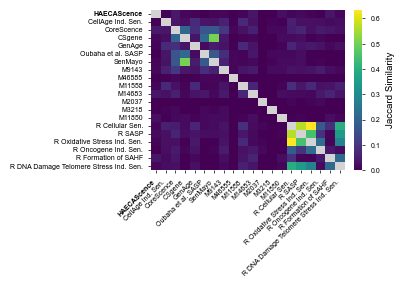

In [16]:
# Plot Jaccard similarity heatmap between gene sets
jaccard_df = compute_jaccard_df(gene_sets)

plt.figure(figsize=(10*cm_to_in, 7*cm_to_in), layout='constrained')

# Compute global color scale across all correlation matrices
all_vals = jaccard_df.values.flatten()
all_vals = [val for val in all_vals if val != 1.0]  # exclude diagonal
vmin, vmax = np.nanmin(all_vals), np.nanmax(all_vals)

ax = sns.heatmap(
    jaccard_df,
    cmap='viridis',
    vmin=vmin,
    vmax=vmax,
    annot=False,
    cbar_kws={'label': 'Jaccard Similarity'}
)

ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=45,
    horizontalalignment='right'
)

# Overwrite diagonal with grey squares
n = jaccard_df.shape[0]
for i in range(n):
    ax.add_patch(
        plt.Rectangle(
            (i, i),       # x, y position
            1, 1,         # width, height
            fill=True,
            color='lightgrey',
            ec='none',
            zorder=3
        )
    )

# Make our geneset labels bold
for tick in ax.get_xticklabels():
    if tick.get_text() in ['HAECAScence', 'HUVECScence']:
        tick.set_fontweight('bold')
for tick in ax.get_yticklabels():
    if tick.get_text() in ['HAECAScence', 'HUVECScence']:
        tick.set_fontweight('bold')

# plt.title('Jaccard Similarity of Senescence Gene Sets')
# plt.tight_layout()
plt.savefig(os.path.join(output_path, 'senescence_gene_sets_jaccard_similarity.pdf'), dpi=300)
plt.show()

In [17]:
# Save Jaccard_df for publication
jaccard_df.to_csv(os.path.join(output_path, 'senescence_gene_sets_jaccard_similarity.csv'))

#Figure S7j: Correlation of signatures

In [ ]:
# Calculate score correlations
gene_sets_purged = {}
for gs_name, genes in gene_sets.items():
    genes_in_data = [gene for gene in genes if gene in adata.var_names]
    gene_sets_purged[gs_name] = genes_in_data

    if gs_name in ['HAECAScence', 'HUVECScence']:
        continue

    genes_haeca_purged = [gene for gene in genes_in_data if gene not in gene_sets['HAECAScence']]
    gene_sets_purged[f"{gs_name}_no_haeca"] = genes_haeca_purged


if not os.path.exists(os.path.join(output_path, 'senescence_scores_atlas_biorxiv_geneset.h5ad')):
    print("Computing senescence scores...")
    uc.compute_ucell_scores(adata, signatures=gene_sets_purged, suffix = '_ucell_score', layer='logcounts')
    
    for gs_name, genes in tqdm(gene_sets_purged.items(), total=len(gene_sets_purged)):
        sc.tl.score_genes(adata, genes, score_name=f'{gs_name}_score', use_raw=False, layer='logcounts')
    # Save the annotated adata
    adata.write_h5ad(os.path.join(output_path, 'senescence_scores_atlas_biorxiv_geneset.h5ad'))
    
else:
    adata = sc.read_h5ad(os.path.join(output_path, 'senescence_scores_atlas_biorxiv_geneset.h5ad'))

score_names = [f'{gs_name}_score' for gs_name in gene_sets_purged.keys()] + [f'{gs_name}_ucell_score' for gs_name in gene_sets_purged.keys()]

correlation_df = compute_score_correlations(adata, score_names)

ucell_score_names = [col for col in adata.obs.columns if 'ucell_score' in col and '_no_h' not in col]
sc_score_names = [col for col in adata.obs.columns if 'score' in col and 'ucell' not in col and '_no_h' not in col]

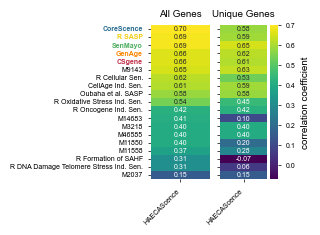

In [23]:
# Build two heatmaps: one for full scores, one for purged scores
# use the rank based ucell scores here
plot_dfs = {}

full_scores = [col for col in adata.obs.columns if 'ucell_score' in col and '_no_h' not in col and not ('HAECAScence' in col or 'HUVECScence' in col)]

plot_dfs['Full Scores'] = correlation_df.loc[full_scores, ['HAECAScence_ucell_score']].copy()
plot_dfs['Full Scores'].index = [name.replace('_ucell_score', '') for name in plot_dfs['Full Scores'].index]
plot_dfs['Full Scores'] = plot_dfs['Full Scores'].sort_values(by='HAECAScence_ucell_score', ascending=False)

purged_haeca_scores = [col for col in adata.obs.columns if 'ucell_score' in col and '_no_haeca' in col and ('HAECAScence' not in col and 'HUVECScence' not in col)]
purged_huvec_scores = [col for col in adata.obs.columns if 'ucell_score' in col and '_no_huvec' in col and ('HAECAScence' not in col and 'HUVECScence' not in col)]

purged_haeca_df = correlation_df.loc[purged_haeca_scores, ['HAECAScence_ucell_score']]
purged_haeca_df.index = [name.replace('_no_haeca_ucell_score', '') for name in purged_haeca_df.index]

plot_dfs['Purged Scores'] = purged_haeca_df.copy()

# Sort both dataframes in the same way
common_indices = plot_dfs['Full Scores'].index
plot_dfs['Full Scores'] = plot_dfs['Full Scores'].loc[common_indices].copy()
plot_dfs['Purged Scores'] = plot_dfs['Purged Scores'].loc[common_indices].copy()

# Rename columns for plotting
plot_dfs['Full Scores'].columns = ['HAECAScence']
plot_dfs['Purged Scores'].columns = ['HAECAScence']

# Find the top5 correlated gene sets
top5_gene_sets = plot_dfs['Full Scores']['HAECAScence'].nlargest(5).index.tolist()
top5_colors = {
    gs: paper_palette[i] for i, gs in enumerate(top5_gene_sets)
}

# Use same color scale for both heatmaps
all_vals = np.concatenate([plot_dfs['Full Scores'].values.flatten(), plot_dfs['Purged Scores'].values.flatten()])
vmin, vmax = np.nanmin(all_vals), np.nanmax(all_vals)

# Plot correlation with our scores both for full and purged scores
fig, axs = plt.subplots(1, 2, figsize=(8*cm_to_in, 6*cm_to_in), sharey=True)
axs = axs.flatten()

for i, (title, plot_df) in enumerate(plot_dfs.items()):
    sns.heatmap(
        plot_df,
        cmap='viridis',
        annot=True,
        fmt=".2f",
        vmin=vmin,
        vmax=vmax,
        ax=axs[i],
        cbar = True if i == 1 else False,
        cbar_kws={'label': 'correlation coefficient'} if i == 1 else None,
        annot_kws={"size": 5}
    )

    if i == 0:
        axs[i].set_title('All Genes')
    else:
        axs[i].set_title('Unique Genes')

    axs[i].set_xticklabels(
        axs[i].get_xticklabels(),
        rotation=45,
        horizontalalignment='right'
    )

# Color the top5 gene sets
for ax in axs:
    for tick in ax.get_yticklabels():
        if tick.get_text() in top5_gene_sets:
            tick.set_color(top5_colors[tick.get_text()])
            tick.set_fontweight('bold')

plt.tight_layout()
plt.savefig(os.path.join(output_path, 'senescence_score_correlations.pdf'), dpi=300)
plt.show()

In [24]:
# Save correlation dfs for publication
for i, (title, plot_df) in enumerate(plot_dfs.items()):
    plot_df.to_csv(os.path.join(output_path, f'correlation_{title}.csv'))